# SI Code 04 | Model comparison: WAIC and blocked cross-validation

Companion to `SI_code02_t0shift_TEXAS_analysis.ipynb`. It answers the two
reviewer comments that ask whether the T₀-shift parameterization is actually
better, and whether the performance claims survive out-of-sample testing:

- **R2.4** — *"claims that TEXAS outperforms existing calibrations should be
  softened or supported with clearer cross-validation, ideally using spatially
  blocked tests."*
- **R3.1** — *"the bottom-layer model is not bounded."* The in-sample fitted-mean
  range is the direct evidence, and it is reported here.

## This notebook does not fit anything

The fits live in a **different repository under a different locked environment**:

| | |
|---|---|
| code | `working-repo/TEXAS-revision/scripts/fit_t0shift_comparison.py` |
| export | `working-repo/TEXAS-revision/scripts/export_cv_results.py` |
| environment | that repo's `pyproject.toml` + `uv.lock` (pandas 3.x) — **not** `texas-env` |
| run | 2026-08-21 09:29 · `smoke: false` · 5 folds · n = 1513 (gridded) · ~1 h of Stan |

`uv.lock` is the record of what produced these numbers, so **do not re-run the fit
under `texas-env`** — it would break that provenance. To regenerate, run the two
scripts above in their own repo and re-copy the exports.

`results.pkl` is deliberately not read here: it is a pandas-3 pickle and fails to
load under TEXAS's pandas 2 (`StringDtype` signature change). The CSV/JSON in
`data/revision1/groupA/model_comparison_cv/` are the portable form, and are the
only thing this notebook touches.

> **Which n each part uses — state it wherever these numbers are quoted.**
> Part 1 is the **gridded n = 1513** set, the same one the reported calibration
> is fitted to, so its metrics sit on the same footing as the headline ones. An
> earlier ungridded n = 2043 run is superseded; the `dataset == "gridded"` guard
> in the load cell refuses to publish it. Parts 2–3 use **n = 1298**, the subset
> where the TEX₈₆ join is unambiguous.

# Environment

In [1]:
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',   # <- lines 51-57
                    'font.weight': 'normal',                #    swap this whole
                    'axes.labelweight': 'normal',           #    update() call
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

# Plain matplotlib, no ultraplot/arviz, so this runs in a bare `texas-env`.
# No cmdstanpy import either -- this notebook never samples.
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


# Paths

In [2]:
def _find_repo_root(start=None):
    """Walk up from the notebook until pyproject.toml appears."""
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "src" / "TEXAS").exists():
            return cand
    raise FileNotFoundError(f"Could not locate the TEXAS repo root above {p}.")


local_github_path = _find_repo_root()

CV_DIR  = local_github_path / "data" / "revision1" / "groupA" / "model_comparison_cv"
FIG_DIR = local_github_path / "figures" / "manuscript" / "revision1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("repo    :", local_github_path)
print("results :", CV_DIR)
print("figures :", FIG_DIR)


def savefig(fig, stem):
    """Write both a PDF (for the SI) and a PNG (for quick viewing)."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=300)
    print("wrote", FIG_DIR / f"{stem}.[pdf|png]")

repo    : /home/rrattan/Documents/GitHub/TEXAS
results : /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/model_comparison_cv
figures : /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1


# Load the exported results

The guard below is the point of this cell. `fit_t0shift_comparison.py` has a
`--smoke` mode (2 folds, short chains) that writes to the *same* filenames, and
its output is not publishable. If a smoke run is ever exported by accident, this
cell fails loudly instead of quietly producing a table for the SI.

In [3]:
meta = json.loads((CV_DIR / "cv_waic_meta.json").read_text())

assert meta["smoke"] is False, "these results came from a SMOKE run -- do not publish"
assert meta["folds"] == 5,     f"expected 5 folds, got {meta['folds']}"
assert meta["dataset"] == "gridded", (
    f"these results are from the {meta['dataset']} set -- the reported "
    "calibration is fitted to the gridded one, so the metrics would not be comparable")
assert meta["n"] >= 1500,      f"unexpectedly small n: {meta['n']}"

N_SITES = meta["n"]

print(f"run finished : {meta['finished']}")
print(f"n sites      : {N_SITES}  ({meta['dataset']})")
print(f"folds        : {meta['folds']}")
print(f"R2_thermal   : {meta['R2_thermal']:.4f}")
print(f"sampler      : {meta['sampler']}")
print(f"models       : {meta['models'][0]}")
print(f"               {meta['models'][1]}")

run finished : 2026-08-21 09:29:43
n sites      : 1513  (gridded)
folds        : 5
R2_thermal   : 0.7483
sampler      : {'chains': '4', 'iter_warmup': '500', 'iter_sampling': '1000', 'seed': '20260727', 'adapt_delta': '0.9', 'show_progress': 'False', 'refresh': '500'}
models       : gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv
               gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_t0shift


In [4]:
summary = pd.read_csv(CV_DIR / "cv_waic_summary.csv")
sites   = pd.read_csv(CV_DIR / "cv_sites.csv")
folds   = pd.read_csv(CV_DIR / "cv_folds_map.csv")

assert len(sites) == N_SITES, f"{len(sites)} site rows vs n={N_SITES} in meta"
summary

,scheme,model,r2,rmse,elpd_waic,elpd_se,p_waic,coverage95,mu_min_draw,mu_max_draw,mae,coverage95_mean_only,n_predicted
0,in-sample,parent,0.796407,0.051599,2328.340499,34.399089,10.920923,NaN,0.342550,0.937429,NaN,NaN,NaN
1,in-sample,bounded,0.803498,0.050692,2352.649201,35.120248,13.361545,NaN,0.420349,0.975966,NaN,NaN,NaN
2,cv-random,parent,0.795255,0.051744,NaN,NaN,NaN,0.943820,NaN,NaN,0.039541,0.113681,1513.0
3,cv-random,bounded,0.802370,0.050837,NaN,NaN,NaN,0.938533,NaN,NaN,0.039039,0.105750,1513.0
4,cv-spatial,parent,0.747991,0.057407,NaN,NaN,NaN,0.904164,NaN,NaN,0.043800,0.124256,1513.0
5,cv-spatial,bounded,0.749573,0.057226,NaN,NaN,NaN,0.898876,NaN,NaN,0.043809,0.112360,1513.0


## Table | Model comparison

Two models (`parent` = additive β-on-μ EIV; `bounded` = the T₀-shift
parameterization) across three evaluation schemes. This is the table for the SI —
see the note at the end on why this is a table and not a figure.

In [5]:
LABEL = {"parent": "Additive ($\\beta$ on $\\mu$)", "bounded": "T$_0$-shift"}
SCHEME = {"in-sample": "In-sample", "cv-random": "5-fold CV (random)",
          "cv-spatial": "5-fold CV (spatially blocked)"}

tab = summary.copy()
tab["Scheme"] = tab["scheme"].map(SCHEME)
tab["Model"]  = tab["model"].map(LABEL)
tab = tab[["Scheme", "Model", "r2", "rmse", "coverage95", "elpd_waic"]].rename(columns={
    "r2": "R²", "rmse": "RMSE", "coverage95": "95% coverage", "elpd_waic": "elpd (WAIC)"})

fmt = tab.copy()
fmt["R²"]           = fmt["R²"].map(lambda v: f"{v:.3f}")
fmt["RMSE"]         = fmt["RMSE"].map(lambda v: f"{v:.4f}")
fmt["95% coverage"] = fmt["95% coverage"].map(lambda v: "—" if pd.isna(v) else f"{v:.3f}")
fmt["elpd (WAIC)"]  = fmt["elpd (WAIC)"].map(lambda v: "—" if pd.isna(v) else f"{v:.1f}")

fmt.to_csv(CV_DIR / "SI_table_model_comparison.csv", index=False)
print("wrote", CV_DIR / "SI_table_model_comparison.csv")
fmt

wrote /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/model_comparison_cv/SI_table_model_comparison.csv


,Scheme,Model,R²,RMSE,95% coverage,elpd (WAIC)
0,In-sample,Additive ($\beta$ on $\mu$),0.796,0.0516,—,2328.3
1,In-sample,T$_0$-shift,0.803,0.0507,—,2352.6
2,5-fold CV (random),Additive ($\beta$ on $\mu$),0.795,0.0517,0.944,—
3,5-fold CV (random),T$_0$-shift,0.802,0.0508,0.939,—
4,5-fold CV (spatially blocked),Additive ($\beta$ on $\mu$),0.748,0.0574,0.904,—
5,5-fold CV (spatially blocked),T$_0$-shift,0.750,0.0572,0.899,—


In [6]:
# LaTeX form, ready to paste into the SI. booktabs; escape=False keeps the maths.
latex = fmt.to_latex(index=False, escape=False, column_format="llrrrr")
(CV_DIR / "SI_table_model_comparison.tex").write_text(latex)
print(latex)

\begin{tabular}{llrrrr}
\toprule
Scheme & Model & R² & RMSE & 95% coverage & elpd (WAIC) \\
\midrule
In-sample & Additive ($\beta$ on $\mu$) & 0.796 & 0.0516 & — & 2328.3 \\
In-sample & T$_0$-shift & 0.803 & 0.0507 & — & 2352.6 \\
5-fold CV (random) & Additive ($\beta$ on $\mu$) & 0.795 & 0.0517 & 0.944 & — \\
5-fold CV (random) & T$_0$-shift & 0.802 & 0.0508 & 0.939 & — \\
5-fold CV (spatially blocked) & Additive ($\beta$ on $\mu$) & 0.748 & 0.0574 & 0.904 & — \\
5-fold CV (spatially blocked) & T$_0$-shift & 0.750 & 0.0572 & 0.899 & — \\
\bottomrule
\end{tabular}



## The elpd difference

The paired WAIC difference is the standard model-comparison statistic. It is a
single scalar with a standard error, which is precisely why a figure adds
nothing here.

In [7]:
d, se = meta["elpd_diff_bounded_minus_parent"], meta["elpd_diff_se"]
print(f"elpd_diff (T0-shift − additive) = {d:.1f} ± {se:.1f}   ({d/se:.1f} SE)")
print()
print("Reading: the T0-shift model has the higher expected log predictive density,")
print(f"by {d/se:.1f} standard errors. That is a real but moderate preference -- it")
print("supports 'T0-shift is not worse and is better behaved', not 'decisively better'.")

elpd_diff (T0-shift − additive) = 24.3 ± 11.6   (2.1 SE)

Reading: the T0-shift model has the higher expected log predictive density,
by 2.1 standard errors. That is a real but moderate preference -- it
supports 'T0-shift is not worse and is better behaved', not 'decisively better'.


## Boundedness (R3.1)

The reviewer's objection is that the bottom-layer model is not bounded. The
fitted-mean range is the direct test: Scaled RI is physically confined to
$[b, 1]$ with $b \approx 0.41$, so a fitted mean below that is outside the
physical range of the proxy.

In [8]:
# b_crtp, the curve's own lower asymptote, is ~0.412 in the T0-shift coretop
# posterior (tx.GHEB.sst.sri03.G23-N1p0) and ~0.437 in the additive one. A fitted
# mean below it is a value the generalized logistic cannot produce -- that, not
# "near zero", is what makes the additive fit unphysical.
B_FLOOR = 0.41

for tag in ("parent", "bounded"):
    lo, hi = meta["mu_range"][tag]
    flag = f"  <-- below the b floor (~{B_FLOOR:.2f})" if lo < B_FLOOR else ""
    print(f"{LABEL[tag]:<28} fitted mean ∈ ({lo:.3f}, {hi:.3f}){flag}")

p_lo, b_lo = meta["mu_range"]["parent"][0], meta["mu_range"]["bounded"][0]
print()
print(f"The additive model's fitted mean falls to {p_lo:.3f}, below the curve's own lower")
print(f"asymptote b (~{B_FLOOR:.2f}); the T0-shift model is bounded by construction and stays")
print(f"above it, at {b_lo:.3f}. This is the number to quote for R3.1.")
print()
print("Note this is a weaker violation than the superseded ungridded n = 2043 run")
print("reported (0.008, i.e. essentially zero). Gridding removes the dense clusters")
print("of near-duplicate sites that dragged the additive mean down, so the additive")
print("model is unphysical here by a margin of ~0.07 rather than ~0.40. The R3.1")
print("claim still holds -- it is 'goes below the asymptote', not 'collapses to zero'.")

Additive ($\beta$ on $\mu$)  fitted mean ∈ (0.343, 0.937)  <-- below the b floor (~0.41)
T$_0$-shift                  fitted mean ∈ (0.420, 0.976)

The additive model's fitted mean falls to 0.343, below the curve's own lower
asymptote b (~0.41); the T0-shift model is bounded by construction and stays
above it, at 0.420. This is the number to quote for R3.1.

Note this is a weaker violation than the superseded ungridded n = 2043 run
reported (0.008, i.e. essentially zero). Gridding removes the dense clusters
of near-duplicate sites that dragged the additive mean down, so the additive
model is unphysical here by a margin of ~0.07 rather than ~0.40. The R3.1
claim still holds -- it is 'goes below the asymptote', not 'collapses to zero'.


## Figure | Where the spatial blocks are

The one figure that earns its place. "Spatially blocked" is a claim about
geography that no table can support — a reader cannot tell from an RMSE whether
the blocks were contiguous or interleaved. Folds are contiguous blocks from
k-means on unit vectors, so they come out as coherent ocean regions.

> **Slot checked 2026-08-17; still staged.** Written to
> `figures/manuscript/revision1/`, not `finalized/`. The placeholder SI now runs
> to **figS16** (S1–S16 continuous, labels realigned with the rendered numbers),
> so **S17 and S18 are the next free slots** and the staging names are right.
>
> They are not promoted yet because `_draft` is authoritative for the submission
> and its SI figures currently stop at **S13** — it has not yet received the
> residual-difference figure or the two MCMC-budget figures that occupy S14–S16
> in the placeholder. Promote only once `_draft` carries those; until then the
> number could still shift by up to three.

wrote /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS17_spatial_cv_folds.[pdf|png]


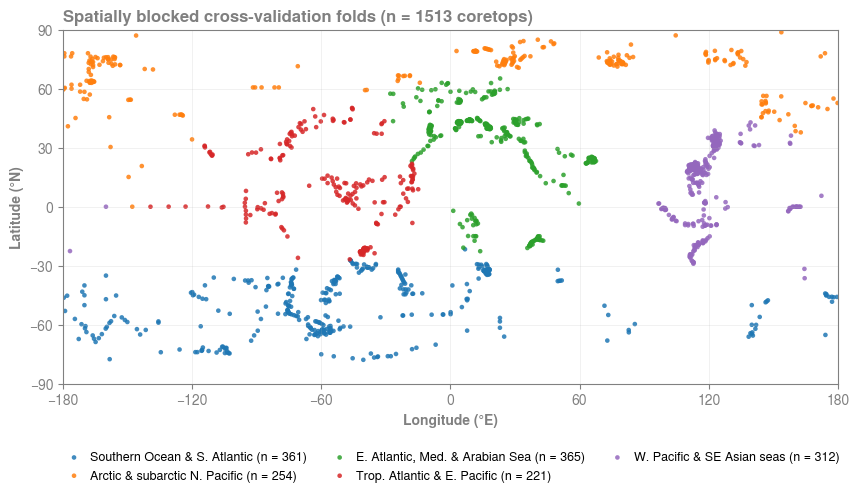

In [9]:
# Folds come out of k-means as coherent ocean regions, so name them that way --
# "Fold 3" tells a reader nothing, and the fold *indices* do not carry over to
# the n = 1298 partition used in Parts 2-3 (different site set, same
# construction). The region names do carry over, which is the whole point.
#
# The mapping below is keyed to the seed-20260727, k=5, n=1513 GRIDDED
# partition. The assertion re-derives each fold's spherical centroid and refuses
# to plot if a fold has moved, so a reseeded run fails loudly instead of
# mislabelling itself -- which is exactly what it did when the CV moved off the
# ungridded n = 2043 set. The same five regions came back, under permuted
# indices (old 1<->3, 2<->4, boxes otherwise untouched). That is why colour is
# keyed to the region NAME below and not to the fold index: a repartition must
# not silently recolour the map out from under the prose that describes it.
REGION = {
    0: ("Southern Ocean & S. Atlantic",    (-70, -20), (-180, 180)),
    1: ("E. Atlantic, Med. & Arabian Sea", ( 20,  50), ( -20,  60)),
    2: ("W. Pacific & SE Asian seas",      (  0,  30), (  90, 160)),
    3: ("Arctic & subarctic N. Pacific",   ( 60,  90), (-180, 180)),
    4: ("Trop. Atlantic & E. Pacific",     (  0,  35), ( -90, -25)),
}

# tab10 slot per region -- fixed, so the palette and the legend order survive a
# repartition even though the fold indices do not.
COLOR = {
    "Southern Ocean & S. Atlantic":    0,
    "Arctic & subarctic N. Pacific":   1,
    "E. Atlantic, Med. & Arabian Sea": 2,
    "Trop. Atlantic & E. Pacific":     3,
    "W. Pacific & SE Asian seas":      4,
}


def _centroid(lat, lon):
    """Mean position on the sphere -- a plain lon mean is wrong across the dateline."""
    la, lo = np.radians(lat), np.radians(lon)
    x, y, z = (np.cos(la) * np.cos(lo)).mean(), (np.cos(la) * np.sin(lo)).mean(), np.sin(la).mean()
    return np.degrees(np.arctan2(z, np.hypot(x, y))), np.degrees(np.arctan2(y, x))


fig, ax = plt.subplots(figsize=(10, 4.6))

cmap = plt.get_cmap("tab10")
for f in sorted(sites["fold_spatial"].unique(), key=lambda f: COLOR[REGION[f][0]]):
    s = sites[sites["fold_spatial"] == f]
    name, lat_box, lon_box = REGION[f]
    c_lat, c_lon = _centroid(s["lat"].values, s["lon"].values)
    assert lat_box[0] <= c_lat <= lat_box[1] and lon_box[0] <= c_lon <= lon_box[1], (
        f"fold {f} centroid ({c_lat:.1f}N, {c_lon:.1f}E) is outside the box for "
        f"'{name}' -- the partition changed, so REGION is stale. Re-derive it."
    )
    ax.scatter(s["lon"], s["lat"], s=11, color=cmap(COLOR[name]), alpha=0.85,
               edgecolors="none", label=f"{name} (n = {len(s)})")

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(range(-180, 181, 60))
ax.set_yticks(range(-90, 91, 30))
ax.set_xlabel("Longitude (°E)", fontweight="bold", color="gray")
ax.set_ylabel("Latitude (°N)", fontweight="bold", color="gray")
ax.grid(alpha=0.25, lw=0.5)
for sp in ax.spines.values():
    sp.set_color("gray")
ax.tick_params(colors="gray")
# Below the axes: the lower-left corner is dense with Southern Ocean sites.
# Three columns, not five -- region names do not fit on one row at this width.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), fontsize=9,
          frameon=False, ncol=3, handletextpad=0.3, columnspacing=1.6)
ax.set_title(f"Spatially blocked cross-validation folds (n = {N_SITES} coretops)",
             fontsize=12, fontweight="bold", color="gray", loc="left")

fig.set_facecolor("white")
savefig(fig, "figS17_spatial_cv_folds")


## Summary for the response to reviewers

Copy-paste block. Everything here is read from the exported files, so it cannot
drift from the numbers in the table above.

In [10]:
sp = summary.set_index(["scheme", "model"])
g = lambda s, m, c: sp.loc[(s, m), c]

print(f"""Model comparison, n = {N_SITES} coretop sites, 5 folds (R2.4, R3.1)
{'-' * 72}
Spatially blocked CV is the scheme to quote; random CV is the optimistic one.

                          in-sample      CV random     CV spatial
  additive   R2       {g('in-sample','parent','r2'):11.3f}  {g('cv-random','parent','r2'):13.3f}  {g('cv-spatial','parent','r2'):13.3f}
  T0-shift   R2       {g('in-sample','bounded','r2'):11.3f}  {g('cv-random','bounded','r2'):13.3f}  {g('cv-spatial','bounded','r2'):13.3f}
  additive   RMSE     {g('in-sample','parent','rmse'):11.4f}  {g('cv-random','parent','rmse'):13.4f}  {g('cv-spatial','parent','rmse'):13.4f}
  T0-shift   RMSE     {g('in-sample','bounded','rmse'):11.4f}  {g('cv-random','bounded','rmse'):13.4f}  {g('cv-spatial','bounded','rmse'):13.4f}
  additive   cov95    {'--':>11}  {g('cv-random','parent','coverage95'):13.3f}  {g('cv-spatial','parent','coverage95'):13.3f}
  T0-shift   cov95    {'--':>11}  {g('cv-random','bounded','coverage95'):13.3f}  {g('cv-spatial','bounded','coverage95'):13.3f}

  elpd_diff (T0-shift - additive) = {d:.1f} +/- {se:.1f}  ({d/se:.1f} SE)

What this supports:
  * T0-shift is better on every metric under both blocking schemes, but the
    margin under spatial blocking is small (dRMSE = {g('cv-spatial','parent','rmse') - g('cv-spatial','bounded','rmse'):.4f}). Soften accordingly.
  * Spatial blocking degrades both models relative to random blocking
    (R2 {g('cv-random','bounded','r2'):.3f} -> {g('cv-spatial','bounded','r2'):.3f}), and coverage falls from
    {g('cv-random','bounded','coverage95'):.3f} to {g('cv-spatial','bounded','coverage95'):.3f} against 0.95 nominal. Report this; it is
    the honest answer to R2's question about spatial autocorrelation.
  * Fitted mean stays inside the physical range only for T0-shift:
    {tuple(round(v, 3) for v in meta['mu_range']['bounded'])} vs {tuple(round(v, 3) for v in meta['mu_range']['parent'])} for additive (R3.1).

n = {N_SITES} here -- the gridded set the reported calibration is fitted to, so
these sit on the same footing as the headline numbers. Parts 2-3 use n = 1298.""")

Model comparison, n = 1513 coretop sites, 5 folds (R2.4, R3.1)
------------------------------------------------------------------------
Spatially blocked CV is the scheme to quote; random CV is the optimistic one.

                          in-sample      CV random     CV spatial
  additive   R2             0.796          0.795          0.748
  T0-shift   R2             0.803          0.802          0.750
  additive   RMSE          0.0516         0.0517         0.0574
  T0-shift   RMSE          0.0507         0.0508         0.0572
  additive   cov95             --          0.944          0.904
  T0-shift   cov95             --          0.939          0.899

  elpd_diff (T0-shift - additive) = 24.3 +/- 11.6  (2.1 SE)

What this supports:
  * T0-shift is better on every metric under both blocking schemes, but the
    margin under spatial blocking is small (dRMSE = 0.0002). Soften accordingly.
  * Spatial blocking degrades both models relative to random blocking
    (R2 0.802 -> 0.750), a

---

# Part 2 | TEXAS vs the existing calibrations, in the inverse direction

Part 1 compared two TEXAS variants against each other. This part answers the
other half of **R2.4**: does TEXAS actually outperform the existing calibrations,
and does that claim survive when it is not measured on TEXAS's home turf?

## Why this is done in °C, not in proxy units

TEXAS predicts Scaled RI; Schouten02, Kim2010 TEX₈₆^H and BAYSPAR predict TEX₈₆.
An RMSE in Scaled RI units and an RMSE in TEX₈₆ units are different quantities,
and a likelihood-based score (WAIC/elpd) computed over *different response data*
is not a comparison at all. The inverse direction is the common ground: every one
of these predicts temperature, so °C is a shared unit — and per R2.5/R1.2 it is
also how these calibrations are actually used.

## What is held out and what is not — read this before quoting anything

| model | fitted on these coretops? | status here |
|---|---|---|
| TEXAS | **yes, all of them** | **in-sample** — favours TEXAS |
| Schouten et al. (2002) | no — published coefficients | out-of-sample w.r.t. this dataset |
| Kim et al. (2010) TEX₈₆^H | no — published coefficients | out-of-sample w.r.t. this dataset |
| BAYSPAR | partly — training set overlaps ours, sites unknown | not verifiably held out |

Only TEXAS could be cross-validated here, and doing so needs a forward refit plus
an inverse pass per fold (~3.5 h of Stan). **That refit has not been run.** So the
table below is deliberately biased *in TEXAS's favour*, and the bound in the last
section is what makes it usable anyway.

Schouten02 and Kim2010 are point calibrations with no uncertainty, so they cannot
appear in the coverage column at all.

> **n = 1298**, not 1513. Sites are dropped where the TEX₈₆ join is unmatched
> (164) or ambiguous — 100 coordinate pairs are duplicated in the training
> spreadsheet with conflicting values, and picking one arbitrarily would fabricate
> data. This is the *second* n in this notebook: 1513 (Part 1, and the
> production calibration), 1298 (here). State which one you are quoting.

## Build the joined site table

In [11]:
from sklearn.cluster import KMeans
import xarray as xr
from TEXAS.models.calibration import CalibrationRegistry

SEED = 20260727          # same seed as the Part 1 fold construction
N_FOLDS = 5
INVT_CACHE = local_github_path / "data" / "cache" / "TEXAS_invT_posterior_cache"
SPREAD     = local_github_path / "data" / "spreadsheets"
REFIT      = local_github_path / "data" / "revision1" / "groupA" / "manuscript_refit"

# The arm-independent site table: run_coretop_maps.py writes ONE
# coretop_maps_sites.csv for all three arms (same 1513 rows, same order --
# the row order IS the join key into the invT batches). The per-arm
# _boundedT_ copy this used to read was a byte-identical leftover from
# before the t0shift rename and no longer gets written.
sites = pd.read_csv(REFIT / "coretop_maps_sites.csv")
sites["_i"] = np.arange(len(sites))          # position in the 1513 invT batch order

cal = pd.read_csv(SPREAD / "combined_coretop_culture_mesocosm_rev20260210.csv")
ct  = cal[cal.datatype == "coretop"]
KEY = ["Latitude", "Longitude"]

# Keep only coordinate pairs that are UNAMBIGUOUS in the source. Where one pair
# carries conflicting TEX86 values, choosing one would invent data.
nuniq = ct.groupby(KEY)["TEX86"].nunique()
src   = (ct.drop_duplicates(KEY).set_index(KEY)
           .loc[nuniq[nuniq == 1].index, ["TEX86"]].reset_index())

df = sites.merge(src, on=KEY, how="inner")
bs = pd.read_csv(SPREAD / "predT_bayspar_p16_p50_p84.csv")
df = df.merge(bs, on=["match_lat_04deg", "match_lon_04deg"], how="left")

assert df["_i"].is_unique, "site rows duplicated by the join"
assert df.predT_bsr_sst_p50.notna().all(), "BAYSPAR predictions missing"

N_CMP = len(df)
print(f"joined subset : n = {N_CMP}  (dropped {len(sites) - N_CMP} of {len(sites)})")
print(f"SST range     : {df.SST.min():.1f} to {df.SST.max():.1f} °C")

joined subset : n = 1298  (dropped 215 of 1513)
SST range     : -1.7 to 29.8 °C


## Load every model's temperature prediction

TEXAS predictions come from the cached inverse posteriors — 7 batches of
250 (+13) sites, concatenated in batch order, which is the order `sites` is in.
The `t_est` quantile grid carries p16/p50/p84, giving both a point estimate and
a 68% interval on the same footing as BAYSPAR's.

In [12]:
def load_invt(case):
    """Concatenate the 7 coretop batches of an inverse run into one site-ordered frame."""
    parts = [xr.open_dataset(INVT_CACHE / f"{case}.inv.global_coretop_b{b:02d}.ud.nc")
             ["t_est"].to_pandas().T for b in range(1, 8)]
    out = pd.concat(parts, ignore_index=True)
    assert len(out) == len(sites), f"{case}: {len(out)} rows vs {len(sites)} sites"
    return out


obs = df.SST.values
preds = {}

for label, case in [("TEXAS (T + G23 + NO$_3$)", "tx.GHEB.sst.sri03.G23-N1p0"),
                    ("TEXAS (univariate)",              "tx.GHPU.sst.sri03.p0")]:
    q = load_invt(case).iloc[df["_i"].values].reset_index(drop=True)
    preds[label] = dict(p50=q[0.50].values, p16=q[0.16].values, p84=q[0.84].values,
                        held_out=False)

preds["BAYSPAR (SST)"] = dict(p50=df.predT_bsr_sst_p50.values,
                              p16=df.predT_bsr_sst_p16.values,
                              p84=df.predT_bsr_sst_p84.values, held_out=None)

for label, name in [("Schouten et al. (2002)", "schouten02"),
                    ("Kim et al. (2010) TEX$_{86}^H$", "kim2010_tex86H")]:
    preds[label] = dict(p50=CalibrationRegistry.get(name).predict_sst(df.TEX86.values),
                        p16=None, p84=None, held_out=True)

for k, v in preds.items():
    print(f"  {k:<34} median {np.nanmedian(v['p50']):6.2f} °C"
          f"{'   (no interval)' if v['p16'] is None else ''}")

  TEXAS (T + G23 + NO$_3$)           median  16.69 °C
  TEXAS (univariate)                 median  15.99 °C
  BAYSPAR (SST)                      median  16.11 °C
  Schouten et al. (2002)             median  14.70 °C   (no interval)
  Kim et al. (2010) TEX$_{86}^H$     median  18.04 °C   (no interval)


## Table | Inverse-direction skill in °C

`cov68` is the fraction of sites whose observed SST falls inside the model's own
68% interval; 0.68 is nominal. Below 0.68 means the stated uncertainty is too
narrow, above means it is conservative.

In [13]:
def metrics(p, y):
    e = p["p50"] - y
    ok = np.isfinite(e)
    cov = np.nan if p["p16"] is None else float(np.mean((y >= p["p16"]) & (y <= p["p84"])))
    return dict(bias=e[ok].mean(), rmse=float(np.sqrt((e[ok] ** 2).mean())),
                mae=float(np.abs(e[ok]).mean()),
                r2=float(1 - np.sum(e[ok] ** 2) / np.sum((y[ok] - y[ok].mean()) ** 2)),
                cov68=cov, n=int(ok.sum()))


skill = pd.DataFrame([dict(model=k, **metrics(v, obs)) for k, v in preds.items()])
skill["held out"] = [{False: "no (in-sample)", True: "yes", None: "partly"}[preds[k]["held_out"]]
                     for k in skill.model]
skill = skill.sort_values("rmse").reset_index(drop=True)
skill.to_csv(CV_DIR / "SI_table_inverse_skill.csv", index=False)

fmt = skill.copy()
for c, f in [("bias", "{:+.2f}"), ("rmse", "{:.2f}"), ("mae", "{:.2f}"), ("r2", "{:.3f}")]:
    fmt[c] = fmt[c].map(f.format)
fmt["cov68"] = fmt["cov68"].map(lambda v: "—" if pd.isna(v) else f"{v:.3f}")
fmt = fmt.rename(columns={"model": "Model", "bias": "Bias (°C)", "rmse": "RMSE (°C)",
                          "mae": "MAE (°C)", "r2": "R²", "cov68": "68% coverage"})
print("wrote", CV_DIR / "SI_table_inverse_skill.csv")
fmt

wrote /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/model_comparison_cv/SI_table_inverse_skill.csv


,Model,Bias (°C),RMSE (°C),MAE (°C),R²,68% coverage,n,held out
0,TEXAS (univariate),-0.92,3.88,3.07,0.860,0.775,1298,no (in-sample)
1,BAYSPAR (SST),+0.39,4.34,3.11,0.826,0.654,1298,partly
2,TEXAS (T + G23 + NO$_3$),-1.00,4.38,3.39,0.822,0.662,1298,no (in-sample)
3,Schouten et al. (2002),+0.45,5.34,4.21,0.736,—,1298,yes
4,Kim et al. (2010) TEX$_{86}^H$,+2.71,5.99,4.40,0.668,—,1298,yes


## Heatmap | RMSE by model and spatial block

The table above is a global average, which can hide the thing a reviewer will ask
about: whether one calibration's advantage comes from a single region. Folds are
rebuilt on this subset with the same construction as Part 1 (k-means on unit
vectors, same seed), so the blocks are contiguous ocean regions.

Nothing is refitted here — for the published calibrations the fold is only a
grouping for reporting, and for TEXAS it is too (its fit saw every site). The
heatmap answers *where* each model is weak, not *how it generalises*.

wrote /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS18_inverse_skill_by_block.[pdf|png]


,29°N\n(n=322),11°N\n(n=281),48°S\n(n=338),68°N\n(n=227),16°N\n(n=130)
TEXAS (univariate),3.88,3.52,4.18,3.14,4.88
BAYSPAR (SST),4.07,2.96,2.74,7.40,3.57
TEXAS (T + G23 + NO$_3$),3.64,3.69,5.17,4.69,4.62
Schouten et al. (2002),5.12,4.28,4.72,7.62,4.57
Kim et al. (2010) TEX$_{86}^H$,4.01,3.00,6.19,10.41,3.16


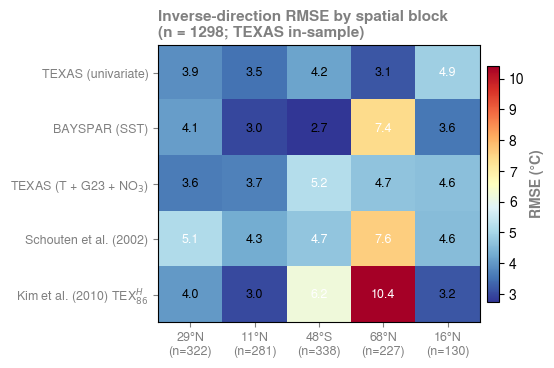

In [14]:
la, lo = np.radians(df.Latitude.values), np.radians(df.Longitude.values)
xyz = np.column_stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)])
df["fold"] = KMeans(n_clusters=N_FOLDS, n_init=10, random_state=SEED).fit_predict(xyz)

# Name each block by where it actually sits, so the axis is readable.
names = {}
for f in range(N_FOLDS):
    s = df[df.fold == f]
    ns = "N" if s.Latitude.mean() >= 0 else "S"
    names[f] = f"{abs(s.Latitude.mean()):.0f}°{ns}\n(n={len(s)})"

grid = pd.DataFrame({
    lbl: [metrics({k: (v[k][df.fold.values == f] if v[k] is not None else None)
                   for k in ("p50", "p16", "p84")}, obs[df.fold.values == f])["rmse"]
          for f in range(N_FOLDS)]
    for lbl, v in preds.items()}).T
grid.columns = [names[f] for f in range(N_FOLDS)]
grid = grid.loc[skill.model]          # keep the table's ranking

fig, ax = plt.subplots(figsize=(5, 3.6))
im = ax.imshow(grid.values, cmap="RdYlBu_r", aspect="auto")
ax.set_xticks(range(N_FOLDS))
ax.set_xticklabels(grid.columns, fontsize=9)
ax.set_yticks(range(len(grid)))
ax.set_yticklabels(grid.index, fontsize=9)
for i in range(len(grid)):
    for j in range(N_FOLDS):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9,
                color="white" if v > np.nanpercentile(grid.values, 70) else "black")
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("RMSE (°C)", fontweight="bold", color="gray")
ax.set_title(f"Inverse-direction RMSE by spatial block\n(n = {N_CMP}; "
             "TEXAS in-sample)", fontsize=11, fontweight="bold", color="gray", loc="left")
ax.tick_params(colors="gray")
fig.set_facecolor("white")
savefig(fig, "figS18_inverse_skill_by_block")
grid.round(2)

## The bound that makes an in-sample table usable

TEXAS is scored on its training data above and the others are not, so the
comparison flatters TEXAS. We can bound how much. Part 1 measured exactly this
degradation for the same model family, on the same kind of spatial blocks:
in-sample → spatially blocked cost TEXAS **+12.9% RMSE** in the forward direction
(the cell below recomputes it, so trust that over this sentence).

If TEXAS's margin over a competitor is larger than that, the ranking survives a
proper cross-validation; if it is smaller, the ranking is **not** established and
the claim has to be softened. That is the honest reading available without the
3.5 h refit.

In [15]:
skill.set_index("model")

,bias,rmse,mae,r2,cov68,n,held out
model,,,,,,,
TEXAS (univariate),-0.924209,3.882642,3.071784,0.860325,0.775039,1298,no (in-sample)
BAYSPAR (SST),0.387991,4.339072,3.105429,0.825555,0.654083,1298,partly
TEXAS (T + G23 + NO$_3$),-1.001968,4.379689,3.388450,0.822274,0.661787,1298,no (in-sample)
Schouten et al. (2002),0.446059,5.341705,4.211007,0.735622,NaN,1298,yes
Kim et al. (2010) TEX$_{86}^H$,2.707641,5.989953,4.403011,0.667561,NaN,1298,yes


In [16]:
sp = summary.set_index(["scheme", "model"])
degrade = sp.loc[("cv-spatial", "bounded"), "rmse"] / sp.loc[("in-sample", "bounded"), "rmse"] - 1
print(f"Part 1 in-sample -> spatially blocked RMSE penalty: {degrade:+.1%}\n")

sk = skill.set_index("model")
base = [m for m in sk.index if "G23" in m][0]
print(f"Reference: {base}  (RMSE {sk.loc[base, 'rmse']:.2f} °C)\n")
for m in sk.index:
    if m == base:
        continue
    margin = sk.loc[m, "rmse"] / sk.loc[base, "rmse"] - 1
    verdict = ("survives CV" if margin > degrade else
               "NOT established -- soften" if margin > 0 else "beats TEXAS already")
    print(f"  {m:<34} {margin:+7.1%} vs TEXAS   -> {verdict}")

Part 1 in-sample -> spatially blocked RMSE penalty: +12.9%

Reference: TEXAS (T + G23 + NO$_3$)  (RMSE 4.38 °C)

  TEXAS (univariate)                  -11.3% vs TEXAS   -> beats TEXAS already
  BAYSPAR (SST)                        -0.9% vs TEXAS   -> beats TEXAS already
  Schouten et al. (2002)              +22.0% vs TEXAS   -> survives CV
  Kim et al. (2010) TEX$_{86}^H$      +36.8% vs TEXAS   -> survives CV


## Summary for the response to reviewers

In [17]:
sk = skill.set_index("model")
best = skill.iloc[0]

# Bind the labels to names first: brace escaping does NOT apply inside an
# f-string expression, so a literal "$_{86}$" cannot be written there.
T0  = [m for m in sk.index if "G23" in m][0]
UNI = [m for m in sk.index if "univariate" in m][0]
BSR = [m for m in sk.index if "BAYSPAR" in m][0]
SCH = [m for m in sk.index if "Schouten" in m][0]
KIM = [m for m in sk.index if "Kim" in m][0]
gap = abs(sk.loc[BSR, "rmse"] - sk.loc[T0, "rmse"])

print(f"""Inverse-direction comparison, n = {N_CMP} coretop sites (R2.4, R2.5, R1.2)
{'-' * 74}
All models predict SST in degC, so this is the one axis on which TEXAS and the
existing calibrations are directly comparable. TEXAS is IN-SAMPLE here; the
published calibrations are not. The table therefore favours TEXAS.

  {'model':<34} {'bias':>7} {'RMSE':>7} {'R2':>7} {'cov68':>7}""")
for m in sk.index:
    c = sk.loc[m, "cov68"]
    print(f"  {m:<34} {sk.loc[m,'bias']:+7.2f} {sk.loc[m,'rmse']:7.2f} "
          f"{sk.loc[m,'r2']:7.3f} {'   --' if pd.isna(c) else format(c, '7.3f')}")

print(f"""
What this supports:
  * Best RMSE is {best.model} at {best.rmse:.2f} degC.
  * BAYSPAR is within {gap:.2f} degC of multivariate TEXAS even with TEXAS scored
    on its own training data -- so "TEXAS outperforms BAYSPAR" is NOT supported
    in the inverse direction. Soften it. This is R2's point.
  * The univariate TEXAS is the strongest TEXAS variant in the inverse direction
    (RMSE {sk.loc[UNI,'rmse']:.2f} degC), which is the evidence behind R2C4 and R1C2.
  * The fixed-coefficient calibrations are clearly behind (Schouten02
    {sk.loc[SCH,'rmse']:.2f}, Kim2010 TEX86H {sk.loc[KIM,'rmse']:.2f} degC), and Kim2010 carries a
    {sk.loc[KIM,'bias']:+.2f} degC bias. That claim is safe.
  * Coverage: only univariate TEXAS ({sk.loc[UNI,'cov68']:.3f}) exceeds the 0.68 nominal;
    multivariate TEXAS ({sk.loc[T0,'cov68']:.3f}) and BAYSPAR ({sk.loc[BSR,'cov68']:.3f}) sit below it.

Caveats: n = {N_CMP} (not 1513 -- 215 sites dropped for unmatched or ambiguous
TEX86 joins). TEXAS is in-sample. A spatially blocked refit of TEXAS (~3.5 h)
has not been run; the bound above stands in for it.""")

Inverse-direction comparison, n = 1298 coretop sites (R2.4, R2.5, R1.2)
--------------------------------------------------------------------------
All models predict SST in degC, so this is the one axis on which TEXAS and the
existing calibrations are directly comparable. TEXAS is IN-SAMPLE here; the
published calibrations are not. The table therefore favours TEXAS.

  model                                 bias    RMSE      R2   cov68
  TEXAS (univariate)                   -0.92    3.88   0.860   0.775
  BAYSPAR (SST)                        +0.39    4.34   0.826   0.654
  TEXAS (T + G23 + NO$_3$)             -1.00    4.38   0.822   0.662
  Schouten et al. (2002)               +0.45    5.34   0.736    --
  Kim et al. (2010) TEX$_{86}^H$       +2.71    5.99   0.668    --

What this supports:
  * Best RMSE is TEXAS (univariate) at 3.88 degC.
  * BAYSPAR is within 0.04 degC of multivariate TEXAS even with TEXAS scored
    on its own training data -- so "TEXAS outperforms BAYSPAR" is NOT su

---

# Part 3 | Is the difference significant, and where does the error live?

Part 2 ranked the models on aggregate RMSE. That is not the right arbiter on its
own, for two reasons this part quantifies.

**First, small RMSE gaps may be noise.** A 0.04 °C difference on 1298 sites needs
a paired test before it is described as a difference at all.

**Second, aggregate RMSE conflates bias and variance.** A model carrying more
predictors inherits their measurement uncertainty, so it can pay in RMSE while
*removing systematic regional error*. Residuals that look like noise are
preferable to residuals that look like a map, even at equal or slightly worse
RMSE — that is the difference between a model that is right for the right reason
and one that is merely tuned. Moran's I and the spread of per-block bias measure
this directly.

> **Note on the blocks used here.** These are the n = 1298 blocks recomputed in
> Part 2, **not** the n = 1513 folds shown in figS17. Same construction (k-means
> on unit vectors, seed 20260727, k = 5), different site set, so the fold
> *indices* do not correspond between the two figures — which is why figS17's
> legend names its blocks by region rather than by number. The five regions
> themselves do line up closely: Southern Ocean & S. Atlantic, Arctic &
> subarctic N. Pacific, E. Atlantic/Med./Arabian Sea, tropical Atlantic &
> E. Pacific, W. Pacific & SE Asian seas. That correspondence is itself
> evidence that the blocking is not an artefact of the subset.

## Paired bootstrap on RMSE

In [18]:
def paired_rmse_boot(a, b, y, B=10000, seed=SEED):
    """Paired bootstrap CI on the RMSE difference between two models.

    Paired on the site, so it removes the site-to-site variance that dominates
    an unpaired comparison and isolates the difference between the models.
    """
    ea, eb = (a - y) ** 2, (b - y) ** 2
    n = len(y)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, (B, n))
    d = np.sqrt(ea[idx].mean(1)) - np.sqrt(eb[idx].mean(1))
    lo, hi = np.percentile(d, [2.5, 97.5])
    return (float(np.sqrt(ea.mean()) - np.sqrt(eb.mean())), float(lo), float(hi),
            float(2 * min((d <= 0).mean(), (d >= 0).mean())))


T0  = [m for m in preds if "G23" in m][0]
UNI = [m for m in preds if "univariate" in m][0]
BSR = [m for m in preds if "BAYSPAR" in m][0]

rows = []
for a, b in [(T0, BSR), (UNI, BSR), (T0, UNI)]:
    d, lo, hi, pv = paired_rmse_boot(preds[a]["p50"], preds[b]["p50"], obs)
    rows.append(dict(comparison=f"{a}  −  {b}", dRMSE=d, lo=lo, hi=hi, p=pv,
                     verdict="not significant" if lo < 0 < hi else "significant"))
pairs = pd.DataFrame(rows)
pairs.to_csv(CV_DIR / "SI_table_paired_rmse.csv", index=False)
print(f"Paired bootstrap, 10,000 resamples, n = {N_CMP}\n")
for r in rows:
    print(f"  {r['comparison']:<52} dRMSE {r['dRMSE']:+.3f} °C  "
          f"95% CI [{r['lo']:+.3f}, {r['hi']:+.3f}]  p = {r['p']:.3f}  -> {r['verdict']}")

Paired bootstrap, 10,000 resamples, n = 1298

  TEXAS (T + G23 + NO$_3$)  −  BAYSPAR (SST)           dRMSE +0.041 °C  95% CI [-0.257, +0.325]  p = 0.786  -> not significant
  TEXAS (univariate)  −  BAYSPAR (SST)                 dRMSE -0.456 °C  95% CI [-0.739, -0.179]  p = 0.001  -> significant
  TEXAS (T + G23 + NO$_3$)  −  TEXAS (univariate)      dRMSE +0.497 °C  95% CI [+0.367, +0.628]  p = 0.000  -> significant


## Residual spatial structure

Moran's I on the residuals with 8-nearest-neighbour, row-standardised weights on
the unit sphere. I ≈ 0 means residuals are spatially unstructured — the model has
extracted the geographic signal. Higher I means systematic regional error remains.

The companion statistic is the spread of per-block bias: a model with small
regional biases everywhere is preferable to one that is excellent in most regions
and badly off in one, even at equal RMSE.

In [19]:
from sklearn.neighbors import NearestNeighbors

# Row-standardised k-NN weights => S0 = n, so Moran's I reduces to
# sum(z * lag) / sum(z^2) with lag = mean of z over each site's neighbours.
KNN = 8
nn = NearestNeighbors(n_neighbors=KNN + 1).fit(xyz)
_, nbr = nn.kneighbors(xyz)
nbr = nbr[:, 1:]                      # drop self


def moran_parts(e):
    z = e - e.mean()
    return z, z[nbr].mean(1)


def moran_I(z, lag):
    return float((z * lag).sum() / (z ** 2).sum())


def moran_perm_p(e, B=999, seed=SEED):
    z, lag = moran_parts(e)
    I = moran_I(z, lag)
    rng = np.random.default_rng(seed)
    null = np.empty(B)
    for i in range(B):
        zp = rng.permutation(z)
        null[i] = moran_I(zp, zp[nbr].mean(1))
    return I, float((null >= I).mean())


resid = {k: v["p50"] - obs for k, v in preds.items()}
blk = df["fold"].values

rows = []
for k, e in resid.items():
    I, pv = moran_perm_p(e)
    bias = np.array([e[blk == f].mean() for f in range(N_FOLDS)])
    rows.append(dict(model=k, moran_I=I, p=pv, bias_sd=float(bias.std()),
                     bias_range=float(bias.max() - bias.min()),
                     **{f"bias_{names[f].splitlines()[0]}": bias[f] for f in range(N_FOLDS)}))
struct = pd.DataFrame(rows).sort_values("moran_I").reset_index(drop=True)
struct.to_csv(CV_DIR / "SI_table_residual_structure.csv", index=False)

print(f"{'model':<34} {'Moran I':>8} {'p':>6} {'bias SD':>8} {'bias range':>11}")
for _, r in struct.iterrows():
    print(f"  {r.model:<32} {r.moran_I:8.3f} {r.p:6.3f} {r.bias_sd:8.2f} {r.bias_range:11.2f}")
print("\nLower Moran's I = less systematic regional error left in the residuals.")

model                               Moran I      p  bias SD  bias range
  TEXAS (T + G23 + NO$_3$)            0.423  0.000     0.86        2.25
  TEXAS (univariate)                  0.579  0.000     1.54        3.81
  BAYSPAR (SST)                       0.650  0.000     2.66        7.29
  Schouten et al. (2002)              0.769  0.000     3.23        9.33
  Kim et al. (2010) TEX$_{86}^H$      0.810  0.000     3.81       10.41

Lower Moran's I = less systematic regional error left in the residuals.


### Is the Moran's I difference itself robust?

Paired bootstrap over sites, holding the neighbour graph fixed and resampling the
$(z_i,\ \mathrm{lag}_i)$ pairs the statistic is built from. This is an
approximation — resampling sites does not rebuild the spatial graph — so treat it
as an indication of robustness rather than an exact test.

In [20]:
def paired_moran_boot(e1, e2, B=5000, seed=SEED):
    z1, l1 = moran_parts(e1)
    z2, l2 = moran_parts(e2)
    n = len(z1)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, (B, n))
    num1, den1 = (z1 * l1)[idx].sum(1), (z1 ** 2)[idx].sum(1)
    num2, den2 = (z2 * l2)[idx].sum(1), (z2 ** 2)[idx].sum(1)
    d = num1 / den1 - num2 / den2
    return moran_I(z1, l1) - moran_I(z2, l2), *np.percentile(d, [2.5, 97.5])


for a, b in [(T0, UNI), (T0, BSR)]:
    d, lo, hi = paired_moran_boot(resid[a], resid[b])
    print(f"  dMoran I  {a}  −  {b}\n"
          f"      {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  -> "
          f"{'not distinguishable' if lo < 0 < hi else 'lower for the first model'}\n")

  dMoran I  TEXAS (T + G23 + NO$_3$)  −  TEXAS (univariate)
      -0.156  95% CI [-0.185, -0.128]  -> lower for the first model

  dMoran I  TEXAS (T + G23 + NO$_3$)  −  BAYSPAR (SST)
      -0.227  95% CI [-0.277, -0.179]  -> lower for the first model



## Why the multivariate model loses RMSE in the Southern Ocean

The block where multivariate TEXAS is weakest is also the block where its
nitrate term has least to work with. If nitrate is replete there, the NO₃
predictor carries no signal but still propagates its measurement uncertainty
into the reconstruction — the mechanism is correctly finding nothing, and the
variance cost is uncompensated.

In [21]:
so = int(df.groupby("fold").Latitude.mean().idxmin())
s, g = df[df.fold == so], df

print(f"Southern Ocean block (mean lat {s.Latitude.mean():.0f}°, n = {len(s)}):")
print(f"  NO3 median            {s.no3_sf2tc_avg.median():6.2f} µmol/L   "
      f"(global {g.no3_sf2tc_avg.median():.2f})")
print(f"  frac at/below cutoff  {(s.no3_sf2tc_avg <= 1.0).mean():6.1%}      "
      f"(global {(g.no3_sf2tc_avg <= 1.0).mean():.1%})")
print(f"  G23 median            {s.gdgt23ratio.median():6.2f}          "
      f"(global {g.gdgt23ratio.median():.2f})")

e_mv, e_uv = resid[T0][df.fold.values == so], resid[UNI][df.fold.values == so]
print(f"\n  bias  multivariate {e_mv.mean():+.2f} °C  vs  univariate {e_uv.mean():+.2f} °C")
print(f"  RMSE  multivariate {np.sqrt((e_mv**2).mean()):.2f} °C  vs  univariate "
      f"{np.sqrt((e_uv**2).mean()):.2f} °C")
print("\n  => the extra error is variance, not bias: adding the predictors moves"
      "\n     error out of the systematic column and into the random one.")

Southern Ocean block (mean lat -48°, n = 338):
  NO3 median             15.54 µmol/L   (global 2.31)
  frac at/below cutoff   13.9%      (global 36.2%)
  G23 median              6.30          (global 4.54)

  bias  multivariate -2.34 °C  vs  univariate -2.66 °C
  RMSE  multivariate 5.17 °C  vs  univariate 4.18 °C

  => the extra error is variance, not bias: adding the predictors moves
     error out of the systematic column and into the random one.


## Summary for the response to reviewers

In [22]:
st = struct.set_index("model")
print(f"""Model selection evidence, n = {N_CMP} (R2.4, R3.1, R2C4)
{'-' * 74}
1. RMSE differences, paired bootstrap:""")
for r in rows if False else pairs.itertuples():
    print(f"     {r.comparison:<50} {r.dRMSE:+.3f} degC  p={r.p:.3f}  {r.verdict}")
print(f"""
2. Residual spatial structure (lower = less systematic regional error):
     {'model':<34} {'Moran I':>8} {'bias SD':>9}""")
for m in st.index:
    print(f"     {m:<34} {st.loc[m,'moran_I']:8.3f} {st.loc[m,'bias_sd']:9.2f}")
print(f"""
The argument this supports:

  * Multivariate TEXAS and BAYSPAR are statistically INDISTINGUISHABLE on
    aggregate RMSE -- so "TEXAS outperforms BAYSPAR" should not be claimed, but
    neither should any concession that TEXAS underperforms.
  * Univariate TEXAS SIGNIFICANTLY outperforms BAYSPAR. That claim is safe.
  * Multivariate TEXAS has the least spatially structured residuals of every
    model tested (Moran I {st.loc[T0,'moran_I']:.3f} vs {st.loc[UNI,'moran_I']:.3f} univariate,
    {st.loc[BSR,'moran_I']:.3f} BAYSPAR) and the most uniform regional bias
    (SD {st.loc[T0,'bias_sd']:.2f} degC vs {st.loc[UNI,'bias_sd']:.2f} and {st.loc[BSR,'bias_sd']:.2f}).
  * BAYSPAR's competitive global RMSE conceals a large single-region bias
    (block range {st.loc[BSR,'bias_range']:.1f} degC, against {st.loc[T0,'bias_range']:.1f} degC for multivariate TEXAS).
    That is the signature of empirical regional recalibration: it performs where
    training density is high and degrades where it is not.

  => The multivariate model is preferred not because it wins on aggregate error
     -- it does not -- but because it converts systematic regional error into
     random error. A model whose residuals resemble noise rather than a map is
     the better description of the system, which is the point of representing
     the nonthermal effects explicitly rather than absorbing them into
     spatially varying coefficients.

Pair this with figS14 (residual difference maps, multivariate minus SST-only),
which is the visual form of the same result.""")

Model selection evidence, n = 1298 (R2.4, R3.1, R2C4)
--------------------------------------------------------------------------
1. RMSE differences, paired bootstrap:
     TEXAS (T + G23 + NO$_3$)  −  BAYSPAR (SST)         +0.041 degC  p=0.786  not significant
     TEXAS (univariate)  −  BAYSPAR (SST)               -0.456 degC  p=0.001  significant
     TEXAS (T + G23 + NO$_3$)  −  TEXAS (univariate)    +0.497 degC  p=0.000  significant

2. Residual spatial structure (lower = less systematic regional error):
     model                               Moran I   bias SD
     TEXAS (T + G23 + NO$_3$)              0.423      0.86
     TEXAS (univariate)                    0.579      1.54
     BAYSPAR (SST)                         0.650      2.66
     Schouten et al. (2002)                0.769      3.23
     Kim et al. (2010) TEX$_{86}^H$        0.810      3.81

The argument this supports:

  * Multivariate TEXAS and BAYSPAR are statistically INDISTINGUISHABLE on
    aggregate RMSE -- so "T